# UHPC Compressive Strength — Model Development

**Author:** K Flowers  
**Date:** January 2026

This notebook develops regression models to predict UHPC compressive strength using the cleaned dataset from notebook 01. Both linear and tree-based models will be compared with cross-validation and tuned with hyperparamter tuning.  The goal is a tuned model achieves prediction accuracy within the ~5-10% variability predicting a  150 MPa UHPC-grade threshold.

**Pipeline Position:** Notebook 2 of 3 — Model Development
- 01_exploratory_analysis.ipynb
- 02_model_development.ipynb ← this notebook
- 03_model_interpretation.ipynb

**Objective:** Build a regression model that predicts compressive strength within the variability of physical testing (~5-10% of mean strength).

**Technical Approach:**
- Prepare data with train/test split (stratified by UHPC threshold of 150 MPa)
- Compare 5 models using cross-validation with default parameters
- Perform hyperparameter tuning on top 2 performers
- Evaluate final model and interpret feature contributions

**Inputs:**
- `data/uhpc_dataset_cleaned.csv` — Cleaned dataset from notebook 01 (792 records)

**Outputs:**
- `data/results/model_results.csv` — Cross-validation results
- `data/results/test_set_predictions.csv` — Test set predictions
- `data/results/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` — Train/test splits for reproducibility
- `data/results/xgb_tuned_model.joblib` — Trained model and artifacts for notebook 03

**Runtime:** ~X minutes

## Model Selection Rationale

Linear Regression will be used to provide an interpretable baseline without regularization. Then, to address multicollinearity identified in EDA and capture potential non-linear relationships, regularized linear models (Ridge, LASSO) and tree-based models (Random Forest, XGBoost) will also be tested.

**Linear Regression** — Baseline model providing interpretable coefficients without regularization.
**Ridge Regression** — L2 regularization to handle correlated features.
**LASSO Regression** — L1 regularization with automatic feature selection.
**Random Forest** — Tree ensemble to capture non-linear relationships.
**XGBoost** — Gradient boosting for comparison on non-linear patterns.

---
## 1. Configure Environment

### 1.1 Import Libraries

In [1]:
# Standard library
from pathlib import Path
import warnings

# Core data libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model building
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model persistence
import joblib

# Display
from IPython.display import display

print("Libraries imported successfully")

Libraries imported successfully


### 1.2 Set Display and Plot Options

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Warnings
warnings.filterwarnings('ignore')

print("Display settings configured")

Display settings configured


### 1.3 Set Paths and Constants

In [3]:
# Project paths
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
IMAGE_DIR = PROJECT_ROOT / "images"

# Create directories if needed
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Input/output files
INPUT_FILE = DATA_DIR / "uhpc_dataset_cleaned.csv"

# Constants
RANDOM_STATE = 42
UHPC_THRESHOLD = 150  # MPa — generally accepted threshold for UHPC classification

print("Paths and constants set")

Paths and constants set


### 1.4 Define Target and Features

In [4]:
# Define target variable and features (matching EDA notebook)
TARGET = 'compressive_strength'

FEATURES = [
    'cement', 'slag', 'silica_fume', 'limestone_powder', 'quartz_powder',
    'fly_ash', 'nano_silica', 'aggregate', 'water', 'fiber',
    'superplasticizer', 'temperature', 'age'
]

print(f"Target: {TARGET}")
print(f"Features: {len(FEATURES)} variables")

Target: compressive_strength
Features: 13 variables


### 1.5 Define Helper Functions

In [ ]:
def record_cv_results(model_name, mae_scores, rmse_scores, r2_scores):
    """Record cross-validation scores into a results dictionary."""
    return {
        'Model': model_name,
        'RMSE_Mean': round(rmse_scores.mean(), 2),
        'RMSE_Std': round(rmse_scores.std(), 2),
        'MAE_Mean': round(mae_scores.mean(), 2),
        'MAE_Std': round(mae_scores.std(), 2),
        'R2_Mean': round(r2_scores.mean(), 4),
        'R2_Std': round(r2_scores.std(), 4)
    }

print("Helper functions defined: record_cv_results")

Helper functions defined: record_cv_results


In [ ]:
def display_standings(results_list):
    """Display current model standings in the order models were run."""
    results_df = pd.DataFrame(results_list)
    
    print(f"\nRESULTS: {len(results_list)} model(s)")
    display(results_df)

print("Helper functions defined: display_standings")

Helper functions defined: display_standings


---
## 2. Load and Prepare Data

### 2.1 Load Dataset

In [7]:
# Load dataset and apply same preprocessing as EDA
df = pd.read_csv(INPUT_FILE)
df.head()

print(f"Dataset loaded: {len(df)} records")
print(f"Features: {len(FEATURES)}")
print(f"Target: {TARGET}")

Dataset loaded: 792 records
Features: 13
Target: compressive_strength


### 2.2 Create Train/Test Split

The data will be stratified by UHPC threshold to ensure both sets have representative samples above and below the threshold.

In [8]:
# Create flag based on UHPC threshold
df['is_uhpc'] = (df[TARGET] >= UHPC_THRESHOLD).astype(int)

# Print strength category value counts
print(df[['is_uhpc']].value_counts())

is_uhpc
0          582
1          210
Name: count, dtype: int64


In [9]:
# Create train/test split stratified
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df['is_uhpc']
)   

print(f"Train/Test Split:")
print(f"  Training set: {len(X_train)} samples")
print(f"  Test set:     {len(X_test)} samples")
print(f"\nUHPC threshold distribution:")
print(f"  Train >= {UHPC_THRESHOLD} MPa: {(y_train >= UHPC_THRESHOLD).mean()*100:.1f}%")
print(f"  Test  >= {UHPC_THRESHOLD} MPa: {(y_test >= UHPC_THRESHOLD).mean()*100:.1f}%")

Train/Test Split:
  Training set: 633 samples
  Test set:     159 samples

UHPC threshold distribution:
  Train >= 150 MPa: 26.5%
  Test  >= 150 MPa: 26.4%


### 2.3 Scaling Note

Linear models (Linear Regression, Ridge, LASSO) are evaluated inside a `Pipeline` that includes `StandardScaler` to ensure scaling is fit only on training folds during cross-validation. Tree-based models (Random Forest, XGBoost) do not require scaling.

---
## 3. Build and Evaluate Models with Cross-Validation

**Methodology:** Models will be built and evaluated using 5-fold cross-validation. RMSE (Root Mean Squared Error) will be used as the primary metric. MAE provides complementary interpretability in engineering units (MPa). R² is included to assess variance explained. Each model will be evaluated with default parameters before hyperparameter tuning.

Each model section:
1. Creates pipeline (with or without scaling)
2. Runs cross-validation (train → predict → evaluate across 5 folds)
3. Displays updated standings

### 3.1 Initialize Cross-Validation

In [10]:
# Create cross-validation splitter with shuffle
cv= KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Initialize results storage
all_model_results = []

print(f"Cross-validation initialized: 5 folds")

Cross-validation initialized: 5 folds


### 3.2 Linear Regression

Baseline model without regularization.

In [11]:
# Create Linear Regression pipeline with scaling
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# Train and evaluate using configured cross-validation
scores = cross_validate(lr_pipeline, X_train, y_train, cv=cv,
                        scoring={'mae': 'neg_mean_absolute_error',
                                 'rmse': 'neg_root_mean_squared_error',
                                 'r2': 'r2'})

# Extract and adjust scores
mae_scores = -scores['test_mae']
rmse_scores = -scores['test_rmse']
r2_scores = scores['test_r2']

# Record model results and display standings
lr_results = record_cv_results('Linear Regression', mae_scores, rmse_scores, r2_scores)
all_model_results.append(lr_results)
display_standings(all_model_results)


RESULTS: 1 model(s)


,Model,RMSE_Mean,RMSE_Std,MAE_Mean,MAE_Std,R2_Mean,R2_Std
0,Linear Regression,22.7600,1.2900,17.9800,0.9600,0.6684,0.0511


### 3.3 Ridge Regression

Apply L2 regularization.

In [12]:
# Create Ridge pipeline with scaling
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

# Train and evaluate using configured cross-validation
scores = cross_validate(ridge_pipeline, X_train, y_train, cv=cv,
                        scoring={'mae': 'neg_mean_absolute_error',
                                 'rmse': 'neg_root_mean_squared_error',
                                 'r2': 'r2'})

# Extract and adjust scores
mae_scores = -scores['test_mae']
rmse_scores = -scores['test_rmse']
r2_scores = scores['test_r2']

# Record model results and display standings
ridge_results = record_cv_results('Ridge', mae_scores, rmse_scores, r2_scores)
all_model_results.append(ridge_results)
display_standings(all_model_results)


RESULTS: 2 model(s)

,Model,RMSE_Mean,RMSE_Std,MAE_Mean,MAE_Std,R2_Mean,R2_Std
0,Linear Regression,22.7600,1.2900,17.9800,0.9600,0.6684,0.0511
1,Ridge,22.7600,1.2600,17.9900,0.9400,0.6684,0.0509


### 3.4 LASSO Regression

Apply L1 regularization.

In [13]:
# Create LASSO pipeline with scaling
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=1.0, random_state=RANDOM_STATE))
])

# Train and evaluate using configured cross-validation
scores = cross_validate(lasso_pipeline, X_train, y_train, cv=cv,
                        scoring={'mae': 'neg_mean_absolute_error',
                                 'rmse': 'neg_root_mean_squared_error',
                                 'r2': 'r2'})

# Extract and adjust scores
mae_scores = -scores['test_mae']
rmse_scores = -scores['test_rmse']
r2_scores = scores['test_r2']

# Record model results and display standings
lasso_results = record_cv_results('LASSO', mae_scores, rmse_scores, r2_scores)
all_model_results.append(lasso_results)
display_standings(all_model_results)


RESULTS: 3 model(s)


,Model,RMSE_Mean,RMSE_Std,MAE_Mean,MAE_Std,R2_Mean,R2_Std
0,Linear Regression,22.7600,1.2900,17.9800,0.9600,0.6684,0.0511
1,Ridge,22.7600,1.2600,17.9900,0.9400,0.6684,0.0509
2,LASSO,23.5000,0.8800,18.9200,0.6300,0.6471,0.0466


**Linear Model Results:** All three linear models showed similar performance (RMSE ~23 MPa, R² ~0.67). Ridge and LASSO regularization did not significantly improve over baseline Linear Regression. This suggests the data contains non-linear relationships or multicollinearity that linear models cannot capture. Tree models will be evaluated next.

### 3.5 Random Forest

Ensemble of decision trees using. Handles non-linear relationships naturally.

In [14]:
# Create Random Forest model — no scaling needed
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

# Train and evaluate using configured cross-validation
scores = cross_validate(rf_model, X_train, y_train, cv=cv,
                        scoring={'mae': 'neg_mean_absolute_error',
                                 'rmse': 'neg_root_mean_squared_error',
                                 'r2': 'r2'})

# Extract and adjust scores
mae_scores = -scores['test_mae']
rmse_scores = -scores['test_rmse']
r2_scores = scores['test_r2']

# Record model results and display standings
rf_results = record_cv_results('Random Forest', mae_scores, rmse_scores, r2_scores)
all_model_results.append(rf_results)
display_standings(all_model_results)


RESULTS: 4 model(s)


,Model,RMSE_Mean,RMSE_Std,MAE_Mean,MAE_Std,R2_Mean,R2_Std
0,Linear Regression,22.7600,1.2900,17.9800,0.9600,0.6684,0.0511
1,Ridge,22.7600,1.2600,17.9900,0.9400,0.6684,0.0509
2,LASSO,23.5000,0.8800,18.9200,0.6300,0.6471,0.0466
3,Random Forest,9.3000,0.8500,6.7800,0.5200,0.9437,0.0140


### 3.6 XGBoost

Gradient boosting builds trees sequentially, with each tree correcting errors from previous trees.

In [15]:
# Create XGBoost model — no scaling needed
xgb_model = XGBRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

# Train and evaluate using configured cross-validation
scores = cross_validate(xgb_model, X_train, y_train, cv=cv,
                        scoring={'mae': 'neg_mean_absolute_error',
                                 'rmse': 'neg_root_mean_squared_error',
                                 'r2': 'r2'})

# Extract and adjust scores
mae_scores = -scores['test_mae']
rmse_scores = -scores['test_rmse']
r2_scores = scores['test_r2']

# Record model results and display standings
xgb_results = record_cv_results('XGBoost', mae_scores, rmse_scores, r2_scores)
all_model_results.append(xgb_results)
display_standings(all_model_results)


RESULTS: 5 model(s)


,Model,RMSE_Mean,RMSE_Std,MAE_Mean,MAE_Std,R2_Mean,R2_Std
0,Linear Regression,22.7600,1.2900,17.9800,0.9600,0.6684,0.0511
1,Ridge,22.7600,1.2600,17.9900,0.9400,0.6684,0.0509
2,LASSO,23.5000,0.8800,18.9200,0.6300,0.6471,0.0466
3,Random Forest,9.3000,0.8500,6.7800,0.5200,0.9437,0.0140
4,XGBoost,8.4100,1.0700,6.0500,0.6300,0.9533,0.0144


**Tree Model Results:** Both tree-based models significantly outperformed linear models (~3x improvement in RMSE). XGBoost (RMSE 8.41) slightly outperformed Random Forest (RMSE 9.30). These two models will proceed to hyperparameter tuning.

### 3.7 Compare Results

Cross-validation performance will be visualized across all models to identify top performers for hyperparameter tuning.

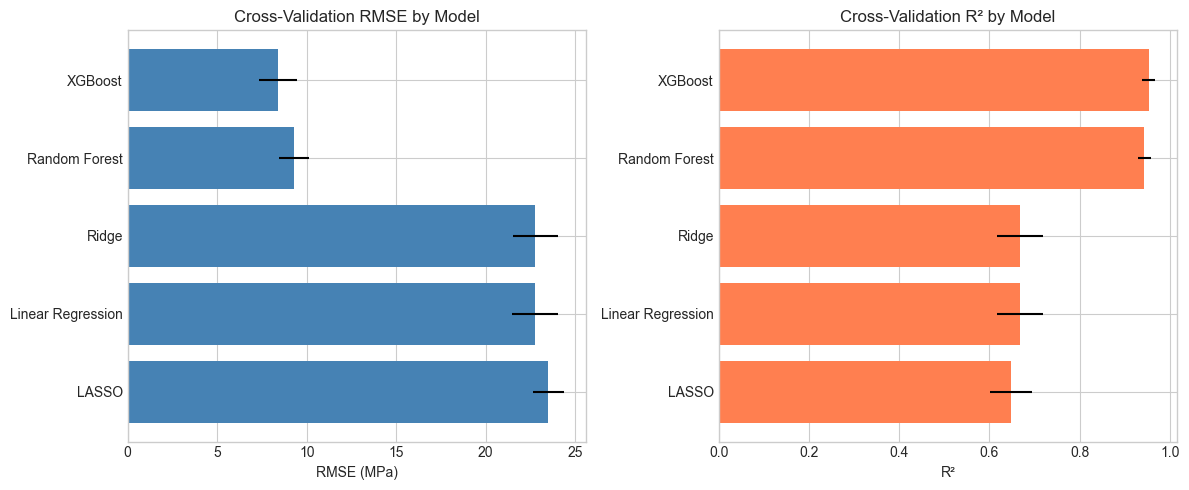

Figure saved: cv_model_comparison.png


In [16]:
# Create visualization of model comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Create results DataFrame sorted by RMSE for visualization
all_model_results_df = pd.DataFrame(all_model_results).sort_values('RMSE_Mean')

# RMSE comparison (left plot)
ax1 = axes[0]
ax1.barh(all_model_results_df['Model'], all_model_results_df['RMSE_Mean'], xerr=all_model_results_df['RMSE_Std'], color='steelblue')
ax1.set_xlabel('RMSE (MPa)')
ax1.set_title('Cross-Validation RMSE by Model')
ax1.invert_yaxis()

# R² comparison (right plot)
ax2 = axes[1]
ax2.barh(all_model_results_df['Model'], all_model_results_df['R2_Mean'], xerr=all_model_results_df['R2_Std'], color='coral')
ax2.set_xlabel('R²')
ax2.set_title('Cross-Validation R² by Model')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig(IMAGE_DIR / 'cv_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: cv_model_comparison.png")

In [17]:
# Identify top performers for hyperparameter tuning
top_2 = all_model_results_df.head(2)['Model'].tolist()
print(f"Top performers for hyperparameter tuning: {top_2}")

Top performers for hyperparameter tuning: ['XGBoost', 'Random Forest']


**Results:**
- **XGBoost** performed best (RMSE 8.41 MPa, R² 0.95), followed by Random Forest (RMSE 9.30)
- **Tree models** outperformed linear models by ~3x — confirms non-linear relationships identified in EDA
- **Regularization** provided no benefit — Ridge and LASSO performed similarly to baseline Linear Regression (RMSE ~23)

---
## 4. Tune Hyperparameters

**Methodology:** GridSearchCV will be used to search hyperparameter combinations for the top 2 performing models. The same 5-fold cross-validation will be used. Parameter ranges are chosen to balance model complexity (depth, estimators) with regularization (learning rate).

### 4.1 Tune XGBoost

XGBoost was the top performer. Key hyperparameters will be tuned: n_estimators, max_depth, and learning_rate.

In [18]:
# Define parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print(f"XGBoost parameter grid: {len(param_grid_xgb['n_estimators']) * len(param_grid_xgb['max_depth']) * len(param_grid_xgb['learning_rate'])} combinations")
print(param_grid_xgb)

XGBoost parameter grid: 27 combinations
{'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.05, 0.1, 0.2]}


In [ ]:
# Run grid search for XGBoost
xgb_model = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)

grid_search_xgb = GridSearchCV(
    xgb_model,
    param_grid_xgb,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search_xgb.fit(X_train, y_train)


# Add tuned XGBoost to results
xgb_tuned_results = {
    'Model': 'XGBoost (tuned)',
    'RMSE_Mean': round(-grid_search_xgb.best_score_, 2),
    'RMSE_Std': np.nan,
    'MAE_Mean': np.nan,
    'MAE_Std': np.nan,
    'R2_Mean': np.nan,
    'R2_Std': np.nan
}

# Display tuned results 
print(f"\nBest parameters: {grid_search_xgb.best_params_}")
print(f"Best CV RMSE: {-grid_search_xgb.best_score_:.2f} MPa")

all_model_results.append(xgb_tuned_results)
display_standings(all_model_results)

Fitting 5 folds for each of 27 candidates, totalling 135 fits



Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
Best CV RMSE: 7.98 MPa

RESULTS: 6 model(s)


,Model,RMSE_Mean,RMSE_Std,MAE_Mean,MAE_Std,R2_Mean,R2_Std
0,Linear Regression,22.7600,1.2900,17.9800,0.9600,0.6684,0.0511
1,Ridge,22.7600,1.2600,17.9900,0.9400,0.6684,0.0509
2,LASSO,23.5000,0.8800,18.9200,0.6300,0.6471,0.0466
3,Random Forest,9.3000,0.8500,6.7800,0.5200,0.9437,0.0140
4,XGBoost,8.4100,1.0700,6.0500,0.6300,0.9533,0.0144
5,XGBoost (tuned),7.9800,NaN,NaN,NaN,NaN,NaN


### 4.2 Tune Random Forest

Random Forest was the second-best performer. Key hyperparameters will be tuned: n_estimators, max_depth, and min_samples_split.

In [ ]:
# Define parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

print(f"Random Forest parameter grid: {len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_split'])} combinations")
print(param_grid_rf)

# Run grid search for Random Forest
rf_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

grid_search_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
grid_search_rf.fit(X_train, y_train)

# Add tuned Random Forest to results
rf_tuned_results = {
    'Model': 'Random Forest (tuned)',
    'RMSE_Mean': round(-grid_search_rf.best_score_, 2),
    'RMSE_Std': np.nan,
    'MAE_Mean': np.nan,
    'MAE_Std': np.nan,
    'R2_Mean': np.nan,
    'R2_Std': np.nan
}

# Display tuned results
print(f"\nBest parameters: {grid_search_rf.best_params_}")
print(f"Best CV RMSE: {-grid_search_rf.best_score_:.2f} MPa")

all_model_results.append(rf_tuned_results)
display_standings(all_model_results)

Random Forest parameter grid: 27 combinations
{'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5, 10]}
Fitting 5 folds for each of 27 candidates, totalling 135 fits



Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Best CV RMSE: 9.25 MPa

RESULTS: 7 model(s)


,Model,RMSE_Mean,RMSE_Std,MAE_Mean,MAE_Std,R2_Mean,R2_Std
0,Linear Regression,22.7600,1.2900,17.9800,0.9600,0.6684,0.0511
1,Ridge,22.7600,1.2600,17.9900,0.9400,0.6684,0.0509
2,LASSO,23.5000,0.8800,18.9200,0.6300,0.6471,0.0466
3,Random Forest,9.3000,0.8500,6.7800,0.5200,0.9437,0.0140
4,XGBoost,8.4100,1.0700,6.0500,0.6300,0.9533,0.0144
5,XGBoost (tuned),7.9800,NaN,NaN,NaN,NaN,NaN
6,Random Forest (tuned),9.2500,NaN,NaN,NaN,NaN,NaN


### 4.3 Compare Tuned Results

**Results:**  XGBoost (tuned) achieved RMSE of 7.98 MPa compared to Random Forest (tuned) at 9.25 MPa. XGBoost will be used for final evaluation on the test set.

---
## 5. Evaluate Final Model

**Methodology:** The tuned model will be evaluated on the held-out test set which contains 20% of data. Diagnostic plots (actual vs. predicted and residuals) will be used to assess prediction quality and identify any patterns in prediction errors.

In [21]:
# Compare tuned models and select final model
tuned_results = pd.DataFrame([
    {'Model': 'XGBoost (tuned)', 'Best_RMSE': round(-grid_search_xgb.best_score_, 2)},
    {'Model': 'Random Forest (tuned)', 'Best_RMSE': round(-grid_search_rf.best_score_, 2)}
]).sort_values('Best_RMSE')

print("TUNED MODEL COMPARISON")
display(tuned_results)

# Select best model
if -grid_search_xgb.best_score_ <= -grid_search_rf.best_score_:
    best_grid_search = grid_search_xgb
    best_model_name = "XGBoost"
else:
    best_grid_search = grid_search_rf
    best_model_name = "Random Forest"

print(f"\nBest model after tuning: {best_model_name}")
print(f"Best parameters: {best_grid_search.best_params_}")

TUNED MODEL COMPARISON


,Model,Best_RMSE
0,XGBoost (tuned),7.9800
1,Random Forest (tuned),9.2500



Best model after tuning: XGBoost
Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}


### 5.1 Generate Predictions on Test Data

In [22]:
# Get best estimator from grid search
final_model = best_grid_search.best_estimator_

print(f"Final model: {best_model_name}")
print(f"Best parameters: {best_grid_search.best_params_}")
print(f"CV RMSE: {-best_grid_search.best_score_:.2f} MPa")

Final model: XGBoost
Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
CV RMSE: 7.98 MPa


In [ ]:
# Generate predictions on held-out test set
y_pred = final_model.predict(X_test)

# Calculate test set metrics
test_results = {
    'Model': best_model_name,
    'MAE': round(mean_absolute_error(y_test, y_pred), 2),
    'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
    'R2': round(r2_score(y_test, y_pred), 4)
}

# Add final model test results to standings
final_test_results = {
    'Model': f'{best_model_name} (test)',
    'RMSE_Mean': test_results['RMSE'],
    'RMSE_Std': np.nan,
    'MAE_Mean': test_results['MAE'],
    'MAE_Std': np.nan,
    'R2_Mean': test_results['R2'],
    'R2_Std': np.nan
}

# Display test set performance
print("TEST SET PERFORMANCE")
print(f"MAE:  {test_results['MAE']:.2f} MPa")
print(f"RMSE: {test_results['RMSE']:.2f} MPa")
print(f"R²:   {test_results['R2']:.4f}")

all_model_results.append(final_test_results)
display_standings(all_model_results)

TEST SET PERFORMANCE
MAE:  4.25 MPa
RMSE: 5.93 MPa
R²:   0.9779

RESULTS: 8 model(s)


,Model,RMSE_Mean,RMSE_Std,MAE_Mean,MAE_Std,R2_Mean,R2_Std
0,Linear Regression,22.7600,1.2900,17.9800,0.9600,0.6684,0.0511
1,Ridge,22.7600,1.2600,17.9900,0.9400,0.6684,0.0509
2,LASSO,23.5000,0.8800,18.9200,0.6300,0.6471,0.0466
3,Random Forest,9.3000,0.8500,6.7800,0.5200,0.9437,0.0140
4,XGBoost,8.4100,1.0700,6.0500,0.6300,0.9533,0.0144
5,XGBoost (tuned),7.9800,NaN,NaN,NaN,NaN,NaN
6,Random Forest (tuned),9.2500,NaN,NaN,NaN,NaN,NaN
7,XGBoost (test),5.9300,NaN,4.2500,NaN,0.9779,NaN


### 5.2 Visualize Predictions

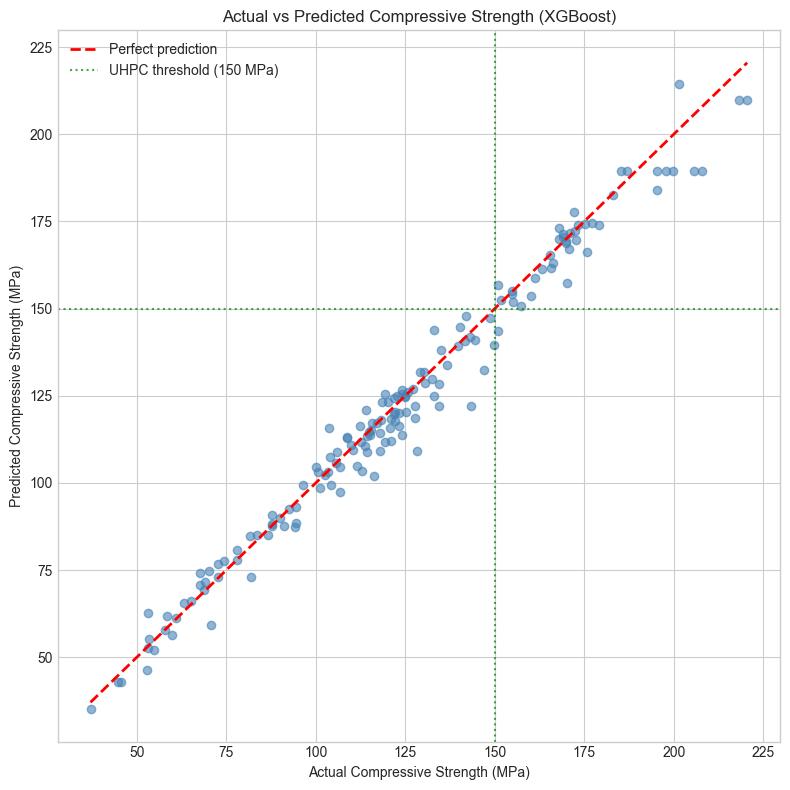

Figure saved: actual_vs_predicted.png


In [24]:
# Create actual vs predicted scatter plot
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred, alpha=0.6, color='steelblue')

# Perfect prediction line
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
        'r--', linewidth=2, label='Perfect prediction')

# UHPC threshold lines
ax.axhline(UHPC_THRESHOLD, color='green', linestyle=':', alpha=0.7,
           label=f'UHPC threshold ({UHPC_THRESHOLD} MPa)')
ax.axvline(UHPC_THRESHOLD, color='green', linestyle=':', alpha=0.7)

ax.set_xlabel('Actual Compressive Strength (MPa)')
ax.set_ylabel('Predicted Compressive Strength (MPa)')
ax.set_title(f'Actual vs Predicted Compressive Strength ({best_model_name})')
ax.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: actual_vs_predicted.png")

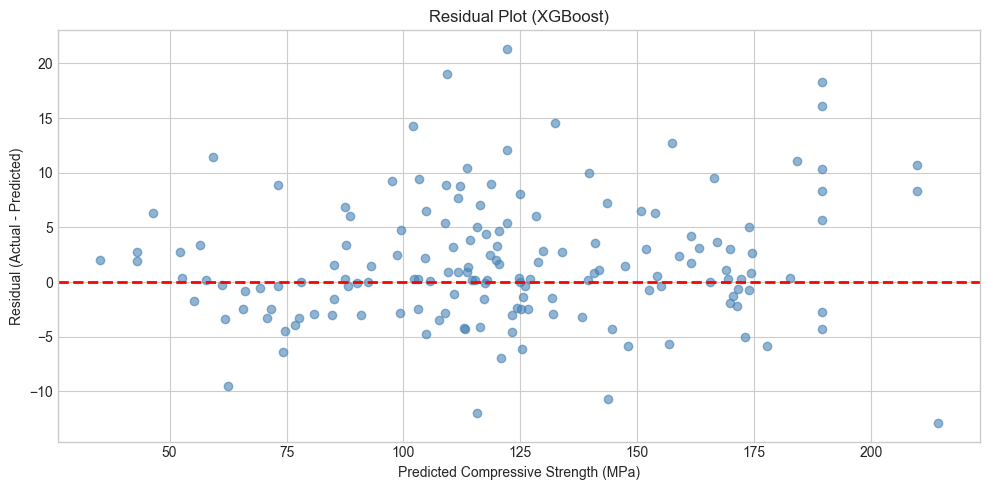

Figure saved: residual_plot.png
Residual statistics:
  Mean: 1.74 MPa
  Std:  5.69 MPa
  Min:  -12.89 MPa
  Max:  21.31 MPa


In [25]:
# Create residual plot
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(y_pred, residuals, alpha=0.6, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=2)

ax.set_xlabel('Predicted Compressive Strength (MPa)')
ax.set_ylabel('Residual (Actual - Predicted)')
ax.set_title(f'Residual Plot ({best_model_name})')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: residual_plot.png")
print("Residual statistics:")
print(f"  Mean: {residuals.mean():.2f} MPa")
print(f"  Std:  {residuals.std():.2f} MPa")
print(f"  Min:  {residuals.min():.2f} MPa")
print(f"  Max:  {residuals.max():.2f} MPa")

**Results:**
- **Predictions up to 200 MPa** are evenly distributed around the perfect prediction line across the full strength range
- **Predictions above 200 MPa** show increased variance which may be due to limited training samples at the high end
- **Residuals** appear randomly distributed around zero with no obvious patterns. This indicates the model can capture underlying relationships without **bias**
- **Test performance** (RMSE 5.93 MPa) exceeded CV performance (RMSE 7.98 MPa), confirming the model **generalizes well** to unseen data

---
## 6. Interpret Model

**Methodology:** Feature importance will be extracted from the final trained XGBoost model to identify which mix design components most influence predictions. Results will be compared to EDA correlation findings. UHPC threshold classification accuracy will be calculated to evaluate how well the model can identify UHPC-grade mixes.

### 6.1 Feature Importance

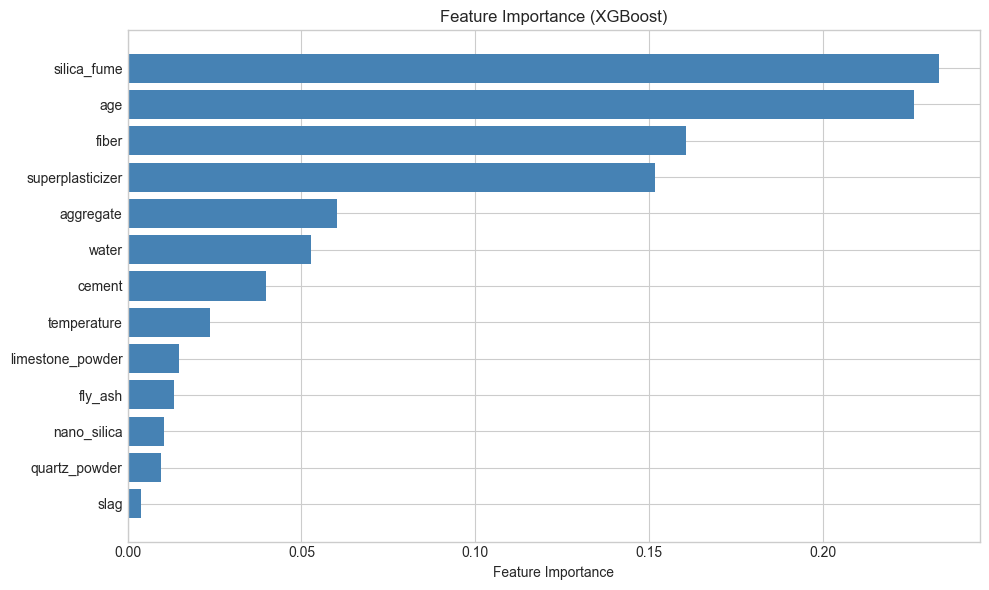

Figure saved: feature_importance.png
Top 5 most important features:
  silica_fume: 0.2335
  age: 0.2262
  fiber: 0.1606
  superplasticizer: 0.1516
  aggregate: 0.0602


In [26]:
# Extract and plot feature importance
importances = final_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title(f'Feature Importance ({best_model_name})')
plt.tight_layout()
plt.savefig(IMAGE_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved: feature_importance.png")
print("Top 5 most important features:")
for idx, row in importance_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

**Results:**
- **Age, silica_fume, and fiber ranked highest** as the top three predictors of compressive strength
- **High multicollinearity identified in EDA may affect these rankings** — correlated features can share importance in tree-based models, making individual contributions harder to isolate
- **SHAP analysis in notebook 03** will provide more detailed feature contribution insights


### 6.4 Bootstrap Prediction Intervals

Bootstrap prediction intervals will be calculated to quantify uncertainty. The model will be retrained on resampled training data and the spread of predictions will be observed. A 95% prediction interval will be used.


In [ ]:
# Retrain XGBoost on N bootstrap resamples, predict with each, use spread as interval
N_BOOTSTRAPS = 200
best_params = best_grid_search.best_params_

np.random.seed(RANDOM_STATE)
bootstrap_predictions = np.zeros((N_BOOTSTRAPS, len(X_test)))

for i in range(N_BOOTSTRAPS):
    # Resample training data with replacement
    boot_idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train.iloc[boot_idx]
    y_boot = y_train.iloc[boot_idx]
    
    # Train model with same hyperparameters
    boot_model = XGBRegressor(**best_params, random_state=i, n_jobs=-1)
    boot_model.fit(X_boot, y_boot)
    
    # Predict on test set
    bootstrap_predictions[i, :] = boot_model.predict(X_test)

# Calculate prediction intervals (2.5th and 97.5th percentiles)
lower_bound = np.percentile(bootstrap_predictions, 2.5, axis=0)
upper_bound = np.percentile(bootstrap_predictions, 97.5, axis=0)
interval_width = upper_bound - lower_bound

print(f"BOOTSTRAP PREDICTION INTERVALS ({N_BOOTSTRAPS} resamples, 95% CI)")
print(f"  Mean interval width:   {interval_width.mean():.2f} MPa")
print(f"  Median interval width: {np.median(interval_width):.2f} MPa")
print(f"  Min interval width:    {interval_width.min():.2f} MPa")
print(f"  Max interval width:    {interval_width.max():.2f} MPa")

# Check coverage: what % of actual values fall within the predicted intervals?
coverage = np.mean((y_test.values >= lower_bound) & (y_test.values <= upper_bound)) * 100
print(f"\n  Coverage: {coverage:.1f}% of actual values fall within 95% prediction intervals")

BOOTSTRAP PREDICTION INTERVALS (200 resamples, 95% CI)
  Mean interval width:   15.46 MPa
  Median interval width: 12.94 MPa
  Min interval width:    4.50 MPa
  Max interval width:    48.09 MPa

  Coverage: 81.8% of actual values fall within 95% prediction intervals


**Results:**
- Bootstrap prediction intervals showed uncertainty bounds around each prediction
- **Coverage was 81.8%** compared to the nominal 95%, indicating intervals are narrower than ideal
- This may be due to a bootstrap limitation and another method may provide better results
- **Next step:** If more precise bounds are needed for engineering decisions, conformal prediction might provide better-calibrated intervals 


## 7. Conclusion

This analysis developed a regression model to predict UHPC compressive strength. The final model achieved RMSE of 5.93 MPa, which falls within the ~5-10% variability typical of physical concrete testing.


**Key Findings:**

- **XGBoost achieved RMSE of 5.93 MPa** (MAE 4.25, R² 0.978) on the held-out test set
- **Tree-based models outperformed linear models by ~3x** — RMSE of 8-9 vs 23 MPa
- **Top predictors were age, silica_fume, and fiber** — though multicollinearity may affect individual rankings
- **Bootstrap prediction intervals** provided uncertainty bounds with 81.8% coverage

**Modeling Approach:**

- Compared 5 models using 5-fold cross-validation with default parameters
- Hyperparameter tuning on top 2 performers (XGBoost, Random Forest)
- Stratified train/test split preserved UHPC threshold distribution (26.5% in both sets)
- Bootstrap resampling (200 iterations) used to generate prediction intervals

**Limitations:**

- Dataset size (n=792) limited hyperparameter search space
- Fiber and aggregate types unspecified — model may not generalize to different material types
- Single random seed used; results could vary with different splits
- Bootstrap intervals underestimated uncertainty (81.8% vs 95% coverage)

**Outputs:**

- `model_results.csv` — Cross-validation results for all models
- `test_set_predictions.csv` — Test set predictions with residuals
- `xgb_tuned_model.joblib` — Trained model for use in notebook 03

**Next Steps:**

- SHAP analysis for detailed feature contributions (notebook 03)
- Conformal prediction for better-calibrated uncertainty bounds
- Validate on external UHPC datasets if available


### A.1 Export Model Comparison

### A.2 Export Test Predictions

In [29]:
# Export test set predictions
predictions_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred,
    'residual': y_test.values - y_pred
})
predictions_df.to_csv(RESULTS_DIR / 'test_set_predictions.csv', index=False)
print(f"Exported: test_set_predictions.csv ({len(predictions_df)} predictions)")

Exported: test_set_predictions.csv (159 predictions)


In [30]:
# Export train/test splits for reproducibility across notebooks
# Why: Ensures notebook 03 (interpretation) uses identical data without relying on random_state
X_train.to_csv(RESULTS_DIR / 'X_train.csv', index=False)
X_test.to_csv(RESULTS_DIR / 'X_test.csv', index=False)
y_train.to_csv(RESULTS_DIR / 'y_train.csv', index=False)
y_test.to_csv(RESULTS_DIR / 'y_test.csv', index=False)

print(f"Exported train/test splits:")
print(f"  X_train.csv: {len(X_train)} samples × {len(FEATURES)} features")
print(f"  X_test.csv:  {len(X_test)} samples × {len(FEATURES)} features")
print(f"  y_train.csv: {len(y_train)} samples")
print(f"  y_test.csv:  {len(y_test)} samples")

Exported train/test splits:
  X_train.csv: 633 samples × 13 features
  X_test.csv:  159 samples × 13 features
  y_train.csv: 633 samples
  y_test.csv:  159 samples


### A.4 Export Model Artifacts

The trained model will be saved for use in notebook 03 (interpretation) without retraining.

In [31]:
# Export trained model and artifacts for use in notebook 03
# Why: Avoids retraining and ensures identical model across notebooks
model_artifacts = {
    'model': final_model,
    'best_params': best_grid_search.best_params_,
    'model_name': best_model_name,
    'feature_names': FEATURES,
    'cv_rmse': -best_grid_search.best_score_
}

joblib.dump(model_artifacts, RESULTS_DIR / 'xgb_tuned_model.joblib')

print(f"Exported model artifacts:")
print(f"  File: xgb_tuned_model.joblib")
print(f"  Model: {best_model_name}")
print(f"  Best params: {best_grid_search.best_params_}")
print(f"  CV RMSE: {-best_grid_search.best_score_:.2f} MPa")

Exported model artifacts:
  File: xgb_tuned_model.joblib
  Model: XGBoost
  Best params: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300}
  CV RMSE: 7.98 MPa


### A.5 Verify Results Directory

All exported files will be listed for verification.

In [32]:
# List all files in the results directory
print(f"RESULTS DIRECTORY: {RESULTS_DIR}\n")
print(f"{'File':<35} {'Size':>10}")
print("-" * 47)

for file in sorted(RESULTS_DIR.iterdir()):
    if file.is_file():
        size_kb = file.stat().st_size / 1024
        print(f"{file.name:<35} {size_kb:>8.1f} KB")

RESULTS DIRECTORY: C:\Users\kristi\OneDrive\04_GitHub_Projects\Data Science Projects\uhpc-concrete-strengh-prediction\data\results

File                                      Size
-----------------------------------------------
final_predictions.csv                    5.6 KB
model_comparison.csv                     0.3 KB
model_results.csv                        0.3 KB
test_set_predictions.csv                 5.6 KB
X_test.csv                               9.7 KB
X_train.csv                             38.4 KB
xgb_tuned_model.joblib                 628.7 KB
y_test.csv                               1.1 KB
y_train.csv                              4.3 KB


### A.3 Export Train/Test Splits

Train/test splits will be saved for exact reproducibility in notebook 03 (interpretation).

---
## Appendix B: References

Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785-794.

Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5-32.

Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.

Federal Highway Administration. (2018). *Properties and Behavior of UHPC-Class Materials* (FHWA-HRT-18-036).